# Interest Rate Swap — Pricing and Risk

## Mechanics

An **interest rate swap (IRS)** exchanges a stream of **fixed** coupon payments for a stream of **floating** payments on a notional principal. The two legs settle periodically (here semi-annually) and the notional is never exchanged.

### Receiver convention

In the **receiver** (long-fixed) convention the holder *receives* the fixed coupon and *pays* the floating rate:

$$
\text{PV}_{\text{receiver}} = \text{PV}_{\text{fixed}} - \text{PV}_{\text{float}}
$$

The fixed leg discounts each coupon at the zero curve:

$$
\text{PV}_{\text{fixed}} = N \cdot \frac{c}{m} \sum_{i=1}^{n} P(0, t_i)
$$

where $c$ is the annual fixed rate, $m$ is coupons per year, and $P(0, t_i)$ is the discount factor to payment date $t_i$.

The floating leg simplifies to:

$$
\text{PV}_{\text{float}} = N \bigl(P(0, t_{\text{settle}}) - P(0, T)\bigr)
$$

because a floating-rate bond prices to par at each reset.

### Par rate

The **par (or swap) rate** is the fixed rate that sets $\text{PV} = 0$:

$$
c^* = m \cdot \frac{P(0, t_{\text{settle}}) - P(0, T)}{\sum_{i=1}^{n} P(0, t_i)}
$$

### DV01

**DV01** (dollar value of 1 basis point) is the change in PV for a 1 bp parallel shift of the zero curve, estimated by finite difference:

$$
\text{DV01} = \frac{\text{PV}(-1\text{bp}) - \text{PV}(+1\text{bp})}{2}
$$

A receiver swap has *positive* DV01: rates falling raises the PV of fixed cash flows.

## 1. Imports and Curve Building

We bootstrap a discount curve from a 3-month deposit and four semi-annual par swaps out to 10 years, matching the setup used in notebook 06.

In [1]:
from neon.lib.fixed_income.bootstrapping.deposit import Deposit
from neon.lib.fixed_income.bootstrapping.swap import Swap
from neon.lib.fixed_income.bootstrapping.bootstrapper import CurveBootstrapper
from neon.lib.fixed_income.irs import InterestRateSwap
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

VALUE_DATE  = '20250101'
SETTLE_DATE = '20250101'

instruments = [
    Deposit(VALUE_DATE, '20250401', rate=0.04),
    Swap(VALUE_DATE, '20260101', fixed_rate=0.044, coupon_freq=2),
    Swap(VALUE_DATE, '20270101', fixed_rate=0.046, coupon_freq=2),
    Swap(VALUE_DATE, '20300101', fixed_rate=0.048, coupon_freq=2),
    Swap(VALUE_DATE, '20350101', fixed_rate=0.050, coupon_freq=2),
]

curve = CurveBootstrapper(value_date=VALUE_DATE, instruments=instruments).build()

print('Curve dates :', curve.dates)
print('Zero rates  :', [f'{r:.4%}' for r in curve.zero_rates])

Curve dates : ['20250401', '20260101', '20270101', '20300101', '20350101']
Zero rates  : ['4.0354%', '4.3784%', '4.5803%', '4.9419%', '5.2764%']


## 2. At-the-Money Receiver Swap

Create a 5-year receiver swap fixed at the par rate. Its PV should be zero (or very close to zero): receiving exactly what the market prices the float leg at.

In [2]:
NOTIONAL     = 1_000_000
MAT_5Y       = '20300101'

# Use a temporary swap to read the par rate first
_tmp = InterestRateSwap(
    value_date=VALUE_DATE,
    maturity_date=MAT_5Y,
    fixed_rate=0.048,   # placeholder — par_rate does not depend on fixed_rate
    notional=NOTIONAL,
    coupon_freq=2,
)
par_rate = _tmp.par_rate(SETTLE_DATE, curve)

# Build the at-the-money swap at the par rate
swap_atm = InterestRateSwap(
    value_date=VALUE_DATE,
    maturity_date=MAT_5Y,
    fixed_rate=par_rate,
    notional=NOTIONAL,
    coupon_freq=2,
)

pv_atm = swap_atm.pv(SETTLE_DATE, curve)

print(f'5yr par rate   : {par_rate:.4%}')
print(f'ATM swap PV    : {pv_atm:,.4f}  (should be ~0)')

5yr par rate   : 4.9847%
ATM swap PV    : 0.0000  (should be ~0)


## 3. Off-Market Swaps

When the fixed rate differs from par the swap has non-zero value. A receiver swap benefits when the agreed fixed rate exceeds the current par rate — it receives above-market coupons.

In [3]:
FIXED_RATE   = 0.048   # as specified: 5yr bootstrap instrument fixed rate

# In-the-money receiver: fixed > par  (we receive above market)
swap_itm = InterestRateSwap(
    value_date=VALUE_DATE,
    maturity_date=MAT_5Y,
    fixed_rate=FIXED_RATE + 0.005,   # par + 50 bp
    notional=NOTIONAL,
    coupon_freq=2,
)

# Out-of-the-money receiver: fixed < par  (we receive below market)
swap_otm = InterestRateSwap(
    value_date=VALUE_DATE,
    maturity_date=MAT_5Y,
    fixed_rate=FIXED_RATE - 0.005,   # par - 50 bp
    notional=NOTIONAL,
    coupon_freq=2,
)

pv_itm = swap_itm.pv(SETTLE_DATE, curve)
pv_otm = swap_otm.pv(SETTLE_DATE, curve)

print(f'Par rate                    : {par_rate:.4%}')
print()
print(f'ITM receiver (fixed = par+50bp): PV = {pv_itm:>12,.2f}')
print(f'ATM receiver (fixed = par)     : PV = {pv_atm:>12,.2f}')
print(f'OTM receiver (fixed = par-50bp): PV = {pv_otm:>12,.2f}')

Par rate                    : 4.9847%

ITM receiver (fixed = par+50bp): PV =    13,853.79
ATM receiver (fixed = par)     : PV =         0.00
OTM receiver (fixed = par-50bp): PV =   -30,088.65


## 4. DV01 — Sensitivity to a 1 bp Rate Shift

DV01 estimates how much the PV changes when all zero rates shift up by 1 basis point. For a receiver swap this is positive: a rate *fall* raises the fixed-leg PV more than it raises the float leg.

In [4]:
swap_dv01 = InterestRateSwap(
    value_date=VALUE_DATE,
    maturity_date=MAT_5Y,
    fixed_rate=FIXED_RATE,
    notional=NOTIONAL,
    coupon_freq=2,
)

dv01 = swap_dv01.dv01(SETTLE_DATE, curve)
pv   = swap_dv01.pv(SETTLE_DATE, curve)

print(f'Fixed rate : {FIXED_RATE:.4%}')
print(f'PV         : {pv:>12,.2f}')
print(f'DV01       : {dv01:>12,.2f}  (USD per 1 bp parallel shift)')
print()
print('Interpretation:')
print(f'  If rates fall 1 bp -> PV change ≈ +{dv01:,.2f}')
print(f'  If rates rise 1 bp -> PV change ≈ -{dv01:,.2f}')

Fixed rate : 4.8000%
PV         :    -8,117.43
DV01       :       446.48  (USD per 1 bp parallel shift)

Interpretation:
  If rates fall 1 bp -> PV change ≈ +446.48
  If rates rise 1 bp -> PV change ≈ -446.48


## 5. PV vs Fixed Rate

Sweep the fixed rate from par minus 200 bp to par plus 200 bp. PV is linear in the fixed rate (the float leg is unaffected) — this is the mark-to-market sensitivity to the coupon struck at inception.

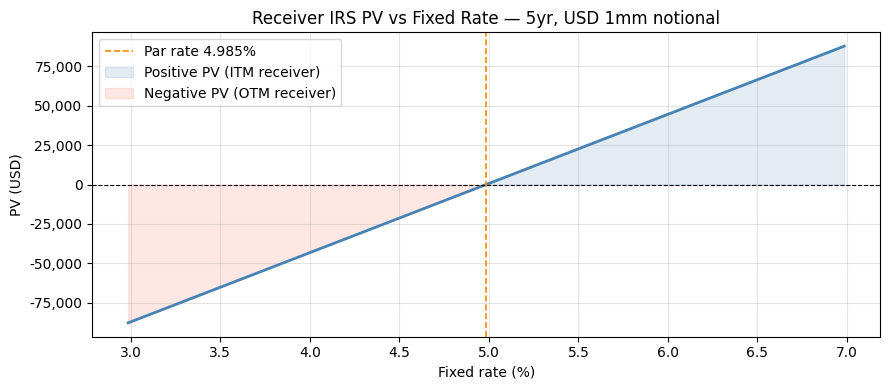

In [5]:
rate_range = np.linspace(par_rate - 0.02, par_rate + 0.02, 200)
pvs = [
    InterestRateSwap(
        value_date=VALUE_DATE,
        maturity_date=MAT_5Y,
        fixed_rate=r,
        notional=NOTIONAL,
        coupon_freq=2,
    ).pv(SETTLE_DATE, curve)
    for r in rate_range
]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rate_range * 100, pvs, color='steelblue', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(par_rate * 100, color='darkorange', linewidth=1.2,
           linestyle='--', label=f'Par rate {par_rate:.3%}')
ax.fill_between(rate_range * 100, pvs, 0,
                where=[p > 0 for p in pvs],
                alpha=0.15, color='steelblue', label='Positive PV (ITM receiver)')
ax.fill_between(rate_range * 100, pvs, 0,
                where=[p < 0 for p in pvs],
                alpha=0.15, color='tomato', label='Negative PV (OTM receiver)')
ax.set_xlabel('Fixed rate (%)')
ax.set_ylabel('PV (USD)')
ax.set_title('Receiver IRS PV vs Fixed Rate — 5yr, USD 1mm notional')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

## 6. DV01 vs Maturity

DV01 grows with tenor because a longer swap accumulates more discounted coupon payments and a more remote float-leg redemption — both of which are more sensitive to rate changes.

We build at-the-money swaps at 1, 2, 3, 5, 7, and 10 years and compare their DV01.

Tenor  Maturity       Par rate         DV01
--------------------------------------------
1Y     20260101        4.4250%        98.91
2Y     20270101        4.6273%       193.29
3Y     20280101        4.8247%       282.79
5Y     20300101        4.9847%       448.63
7Y     20320101        5.1602%       595.67
10Y    20350101        5.2914%       787.31


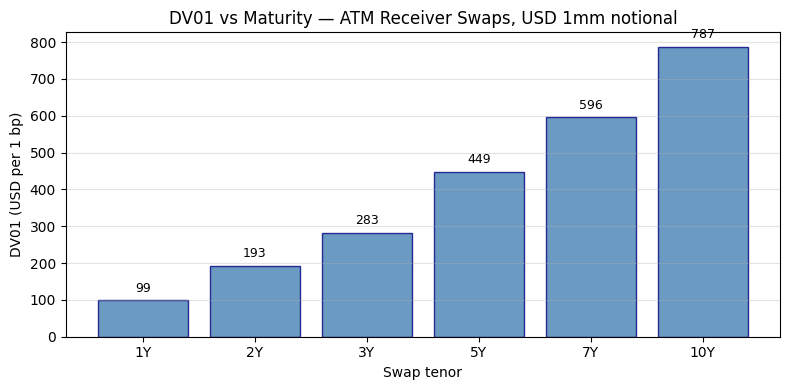

In [6]:
tenor_maturities = {
    '1Y': '20260101',
    '2Y': '20270101',
    '3Y': '20280101',
    '5Y': '20300101',
    '7Y': '20320101',
    '10Y': '20350101',
}

results = []
print(f"{'Tenor':<6} {'Maturity':<12} {'Par rate':>10} {'DV01':>12}")
print('-' * 44)

for label, mat in tenor_maturities.items():
    # Query par rate from a reference swap
    _ref = InterestRateSwap(
        value_date=VALUE_DATE,
        maturity_date=mat,
        fixed_rate=0.048,
        notional=NOTIONAL,
        coupon_freq=2,
    )
    pr = _ref.par_rate(SETTLE_DATE, curve)

    # Build at-the-money swap and compute DV01
    atm = InterestRateSwap(
        value_date=VALUE_DATE,
        maturity_date=mat,
        fixed_rate=pr,
        notional=NOTIONAL,
        coupon_freq=2,
    )
    d = atm.dv01(SETTLE_DATE, curve)
    results.append((label, pr, d))
    print(f'{label:<6} {mat:<12} {pr:>10.4%} {d:>12,.2f}')

tenors_plot = [r[0] for r in results]
dv01s_plot  = [r[2] for r in results]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tenors_plot, dv01s_plot, color='steelblue', edgecolor='navy', alpha=0.8)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Swap tenor')
ax.set_ylabel('DV01 (USD per 1 bp)')
ax.set_title('DV01 vs Maturity — ATM Receiver Swaps, USD 1mm notional')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, axis='y', alpha=0.35)
plt.tight_layout()
plt.show()